# Step 4 — UNet Training & Experiments

This notebook trains the UNet model on the preprocessed nuclei segmentation dataset and runs ablation experiments to justify design choices.

**What this notebook does:**
- Loads the preprocessed train, validation, and test splits
- Trains UNet using combined BCE + Dice loss
- Saves the best model checkpoint based on validation Dice score
- Produces training curves and visual predictions
- Runs three ablation experiments: learning rate, loss function, augmentation
- Evaluates final model on held-out test set

---

| | |
|:---|:---|
| **Dataset** | 2018 Kaggle Data Science Bowl — Nuclei Segmentation |
| **Model** | UNet — Ronneberger et al., MICCAI 2015 |
| **Loss** | Combined BCE + Dice |
| **Optimizer** | Adam with ReduceLROnPlateau scheduler |
| **Epochs** | Defined in configs/config.yaml |
| **Best Val Dice** | 0.9180 |

## 1. Environment Setup

Mount Google Drive, clone the project repository, and install all required libraries.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Clone the latest version from GitHub
!git clone https://github.com/Norhankamal/Medical-Image-Segmentation-with-UNet-Variants.git

Cloning into 'Medical-Image-Segmentation-with-UNet-Variants'...
remote: Enumerating objects: 513, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 513 (delta 92), reused 23 (delta 23), pack-reused 328 (from 2)
Receiving objects: 100% (513/513), 27.83 MiB | 17.96 MiB/s, done.
Resolving deltas: 100% (183/183), done.


In [ ]:
!pip install torch torchvision pyyaml opencv-python matplotlib tqdm torchsummary -q

In [ ]:
# Fix non-breaking spaces in evaluate.py that cause IndentationError
with open('/content/Medical-Image-Segmentation-with-UNet-Variants/src/evaluate.py', 'r') as f:
    content = f.read()
content = content.replace('\u00a0', ' ')
with open('/content/Medical-Image-Segmentation-with-UNet-Variants/src/evaluate.py', 'w') as f:
    f.write(content)
print('evaluate.py encoding fixed.')

evaluate.py encoding fixed.


## 2. Verify Data & Hardware

Confirm the three `.npz` archives are accessible on Drive and GPU is available.

In [ ]:
import os

base = '/content/drive/MyDrive/Medical_Segmentation_Data/preprocessed'
print('Preprocessed files:')
for f in sorted(os.listdir(base)):
    size = os.path.getsize(f'{base}/{f}') / (1024**2)
    print(f'  {f:<35} {size:.1f} MB')

Preprocessed files:
  test_preprocessed.npz               10.7 MB
  train_preprocessed.npz              51.0 MB
  val_preprocessed.npz                11.1 MB


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: GPU not available. Go to Runtime > Change runtime type > T4 GPU')

Device: cuda


## 3. Main Training Run

Train UNet using the hyperparameters defined in `configs/config.yaml`.
The best model checkpoint is saved automatically based on validation Dice score.

In [ ]:
# Run the full training pipeline
# All hyperparameters are read from configs/config.yaml
# Logs: Train Loss | Val Loss | Dice | IoU per epoch
# Best model saved to checkpoints/best_model.pth
!cd /content/Medical-Image-Segmentation-with-UNet-Variants && python -m src.train

Device: cuda

Training UNet for 30 epochs

 Epoch   Train Loss   Val Loss     Dice      IoU
--------------------------------------------------
     1       1.2225     1.0199   0.7670   0.6253
         -> best model saved (Dice 0.7670)
     2       0.9533     0.8309   0.8738   0.7773
         -> best model saved (Dice 0.8738)
     3       0.8527     0.7564   0.8863   0.7970
         -> best model saved (Dice 0.8863)
     4       0.7976     0.7314   0.8835   0.7931
     5       0.7431     0.6752   0.8909   0.8045
         -> best model saved (Dice 0.8909)
     6       0.6919     0.6887   0.8825   0.7910
     7       0.6513     0.6428   0.8886   0.8013
     8       0.6027     0.5633   0.8953   0.8111
         -> best model saved (Dice 0.8953)
     9       0.5696     0.5158   0.9016   0.8219
         -> best model saved (Dice 0.9016)
    10       0.5294     0.5269   0.9028   0.8239
         -> best model saved (Dice 0.9028)
    11       0.5008     0.4592   0.9031   0.8247
         -> best 

## 4. Training Results

Training curves, prediction visualizations, and final metrics saved to `reports/figures/`.

Training and Validation Curves:


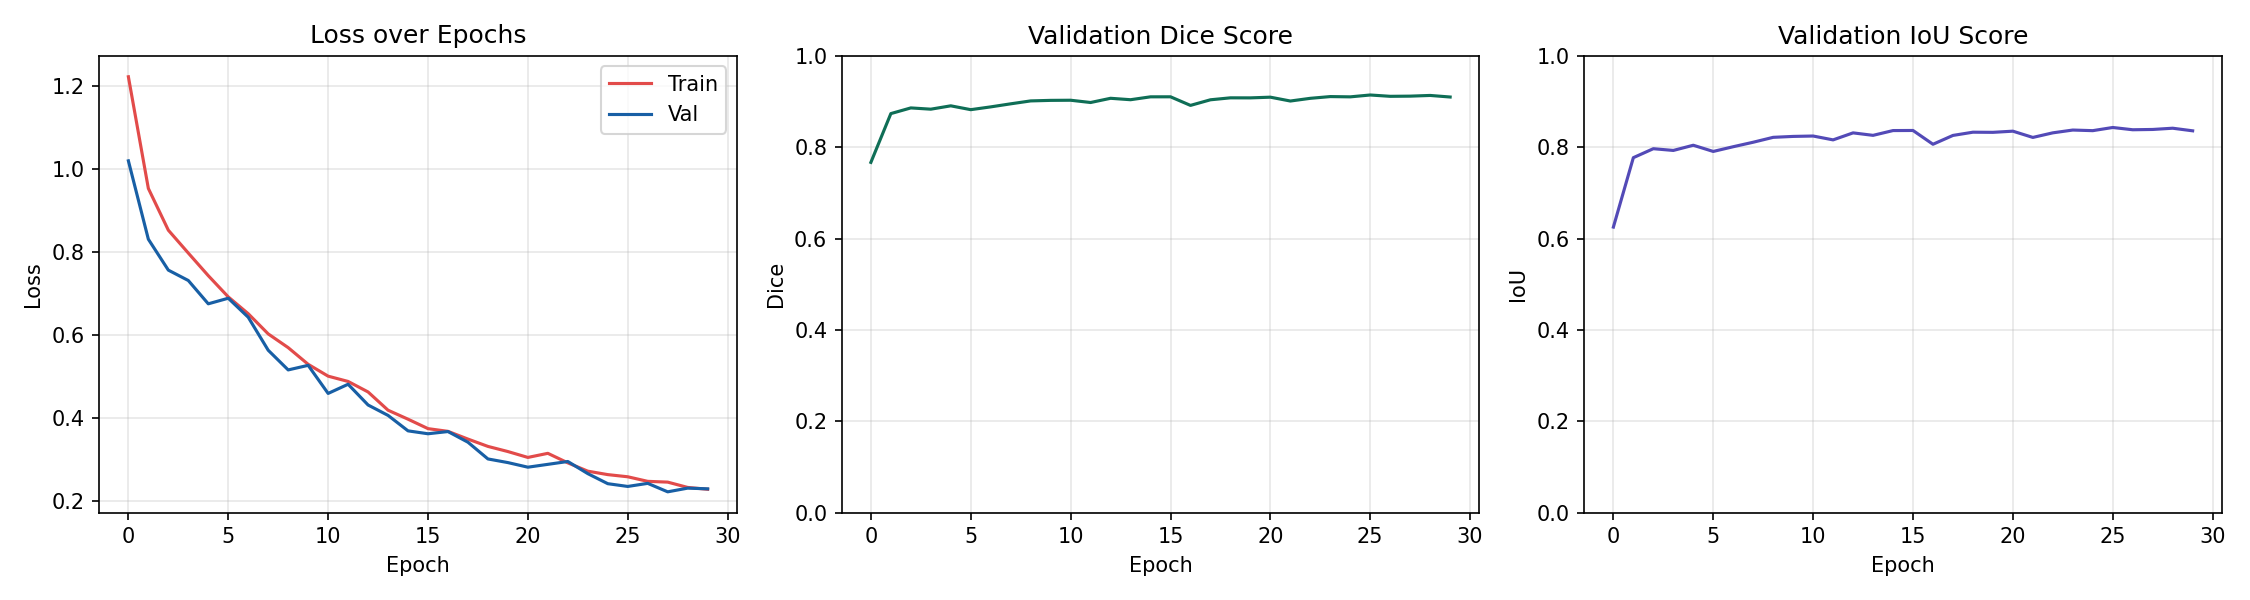

In [ ]:
from IPython.display import Image, display
print('Training and Validation Curves:')
display(Image('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/training_curves.png'))

Model Predictions vs Ground Truth:


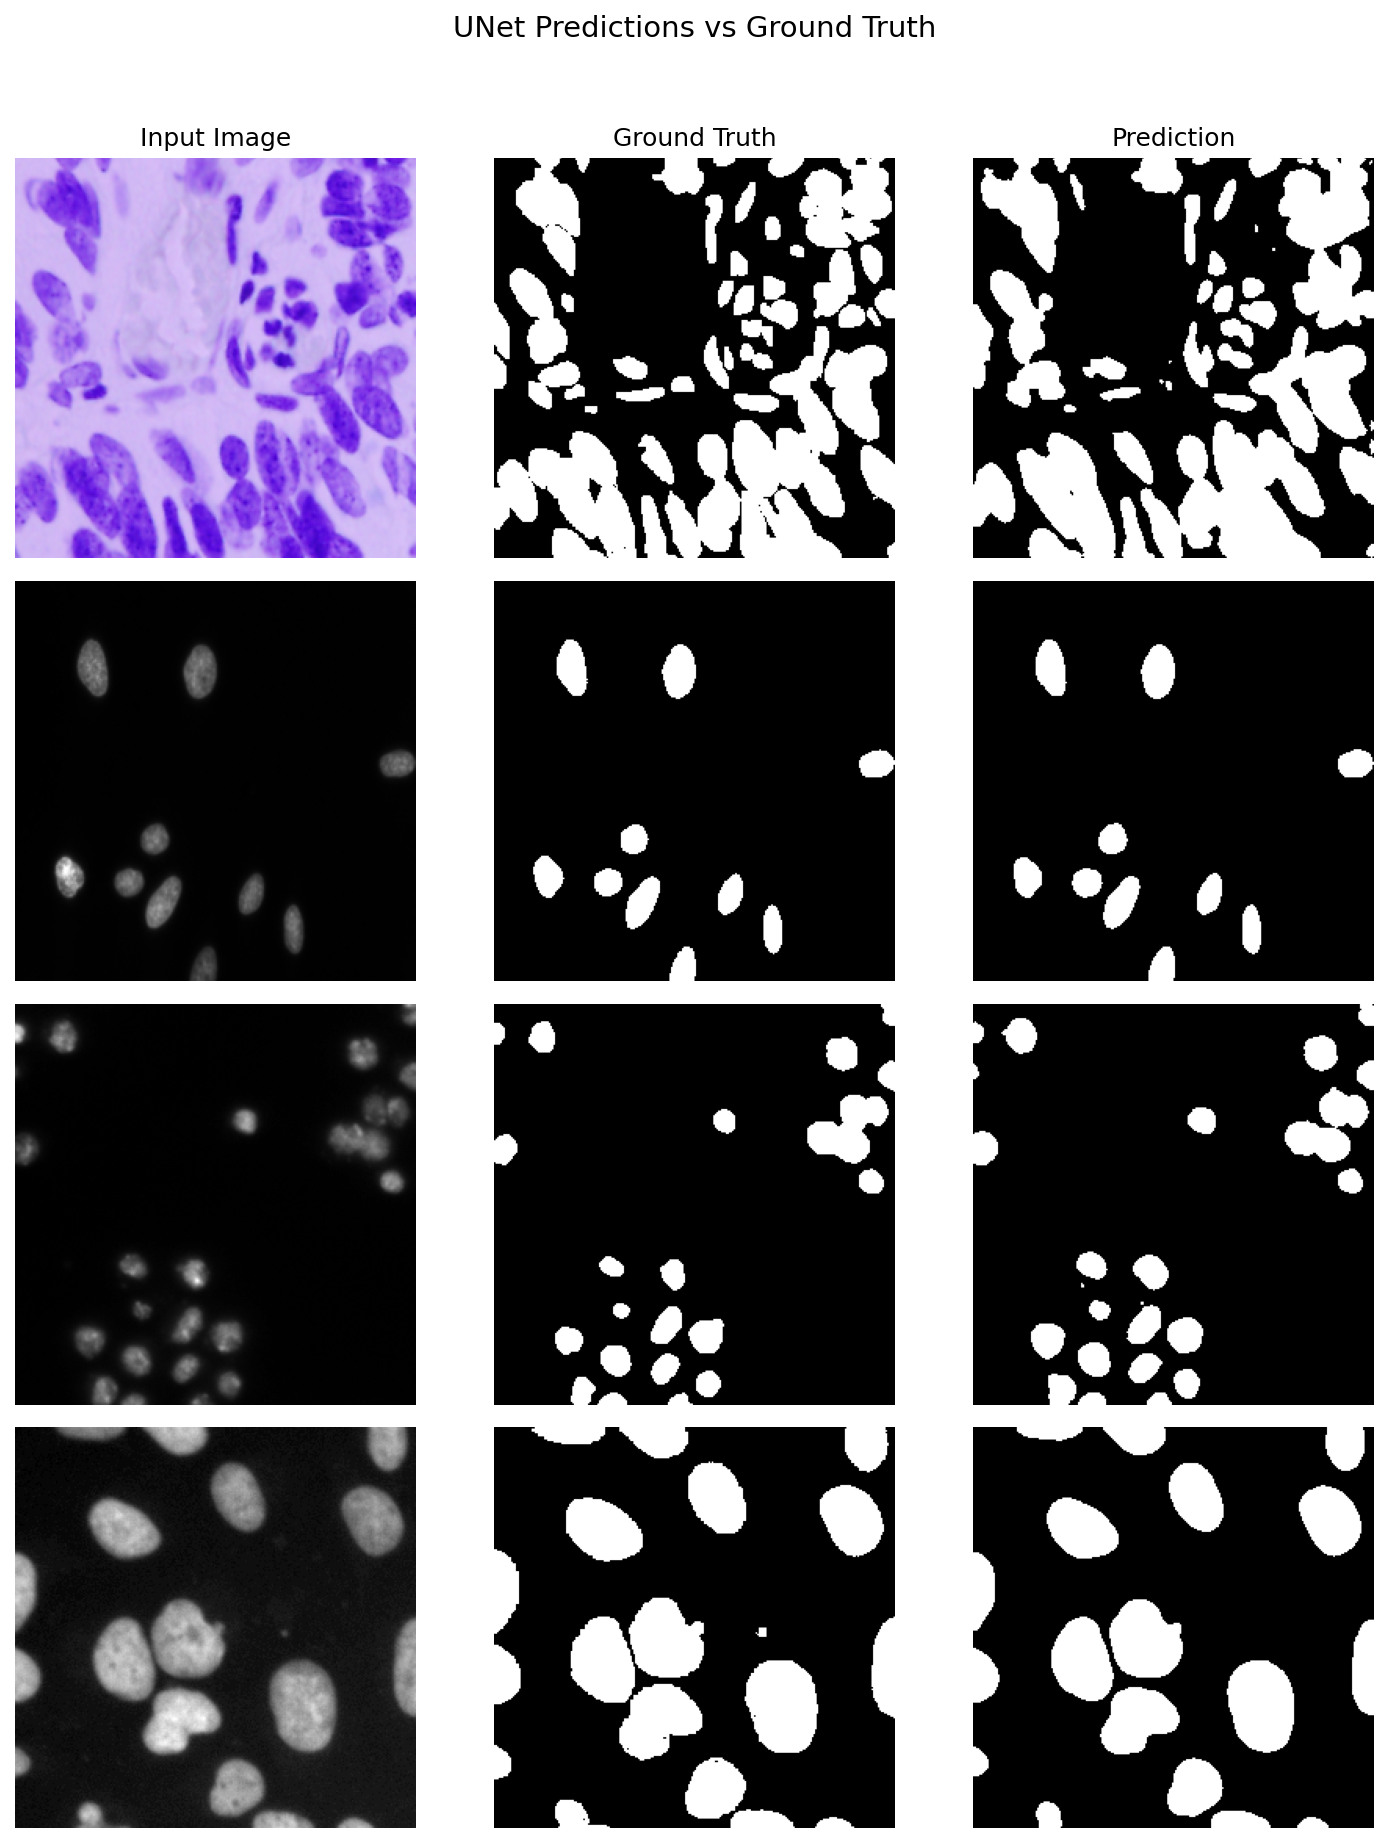

In [ ]:
print('Model Predictions vs Ground Truth:')
display(Image('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/predictions.png'))

In [ ]:
with open('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/metrics.txt') as f:
    print(f.read())

Final Evaluation Results
Model    : UNet
Dataset  : 2018 Data Science Bowl

val_dice            : 0.9146
val_iou             : 0.8434
val_loss            : 0.2220



## 5. Ablation Experiments

We run three experiments to justify the design choices made in the final model.
All experiments use 30 epochs for efficiency. Only one variable changes per experiment.

| Experiment | Variable | Values Tested |
|---|---|---|
| 1 | Learning rate | 0.001, 0.0001, 0.00001 |
| 2 | Loss function | BCE only, BCE + Dice |
| 3 | Data augmentation | Without, With |

In [ ]:
# Shared setup for all experiments
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

sys.path.insert(0, '/content/Medical-Image-Segmentation-with-UNet-Variants')

from src.model    import UNet
from src.dataset  import get_dataloaders
from src.evaluate import dice_score, iou_score
from src.train    import BCEDiceLoss, train_one_epoch, validate

with open('/content/Medical-Image-Segmentation-with-UNet-Variants/configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, val_loader, test_loader = get_dataloaders(cfg)

EXPERIMENT_EPOCHS = 30
print(f'Device           : {device}')
print(f'Experiment epochs: {EXPERIMENT_EPOCHS}')
print(f'Train samples    : {len(train_loader.dataset)}')
print(f'Val samples      : {len(val_loader.dataset)}')
print(f'Test samples     : {len(test_loader.dataset)}')

Device           : cuda
Experiment epochs: 30
Train samples    : 469
Val samples      : 100
Test samples     : 101


### Experiment 1 — Learning Rate Comparison

Train the model three times with different learning rates. All other settings identical.

**Hypothesis:** lr=0.0001 will perform best — high lr causes instability, low lr converges too slowly in 30 epochs.

In [ ]:
learning_rates = [0.001, 0.0001, 0.00001]
lr_results     = []

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f'Learning rate: {lr}')
    print(f"{'='*50}")

    model = UNet(
        in_channels  = cfg['model']['in_channels'],
        out_channels = cfg['model']['out_channels']
    ).to(device)

    criterion = BCEDiceLoss(
        bce_weight  = cfg['loss']['bce_weight'],
        dice_weight = cfg['loss']['dice_weight']
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience = cfg['training']['lr_patience'],
        factor   = cfg['training']['lr_factor']
    )

    best_dice = 0.0
    best_iou  = 0.0
    best_loss = float('inf')

    for epoch in range(1, EXPERIMENT_EPOCHS + 1):
        trn_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        if val_dice > best_dice:
            best_dice = val_dice
            best_iou  = val_iou
            best_loss = val_loss

        if epoch % 10 == 0 or epoch == EXPERIMENT_EPOCHS:
            print(f'  Epoch {epoch:>3} | Loss {val_loss:.4f} | Dice {val_dice:.4f} | IoU {val_iou:.4f}')

    lr_results.append({'label': f'lr={lr}', 'lr': lr, 'val_dice': best_dice, 'val_iou': best_iou, 'val_loss': best_loss})
    print(f'  Best Dice: {best_dice:.4f} | Best IoU: {best_iou:.4f}')

print(f"\n{'='*50}")
print('Experiment 1 Summary')
print(f"{'LR':<12} {'Dice':>8} {'IoU':>8}")
print('-' * 30)
for r in lr_results:
    print(f"{r['lr']:<12} {r['val_dice']:>8.4f} {r['val_iou']:>8.4f}")
best_lr = max(lr_results, key=lambda x: x['val_dice'])
print(f"\nBest: lr={best_lr['lr']} (Dice={best_lr['val_dice']:.4f})")


Learning rate: 0.001
  Epoch  10 | Loss 0.3315 | Dice 0.8348 | IoU 0.7219
  Epoch  20 | Loss 0.3501 | Dice 0.8762 | IoU 0.7833
  Epoch  30 | Loss 0.2576 | Dice 0.8902 | IoU 0.8051
  Best Dice: 0.9067 | Best IoU: 0.8305

Learning rate: 0.0001
  Epoch  10 | Loss 0.4480 | Dice 0.8997 | IoU 0.8187
  Epoch  20 | Loss 0.2841 | Dice 0.9097 | IoU 0.8353
  Epoch  30 | Loss 0.2160 | Dice 0.9116 | IoU 0.8384
  Best Dice: 0.9123 | Best IoU: 0.8397

Learning rate: 1e-05
  Epoch  10 | Loss 0.8642 | Dice 0.8806 | IoU 0.7876
  Epoch  20 | Loss 0.8015 | Dice 0.8987 | IoU 0.8167
  Epoch  30 | Loss 0.7324 | Dice 0.9022 | IoU 0.8225
  Best Dice: 0.9022 | Best IoU: 0.8225

Experiment 1 Summary
LR               Dice      IoU
------------------------------
0.001          0.9067   0.8305
0.0001         0.9123   0.8397
1e-05          0.9022   0.8225

Best: lr=0.0001 (Dice=0.9123)


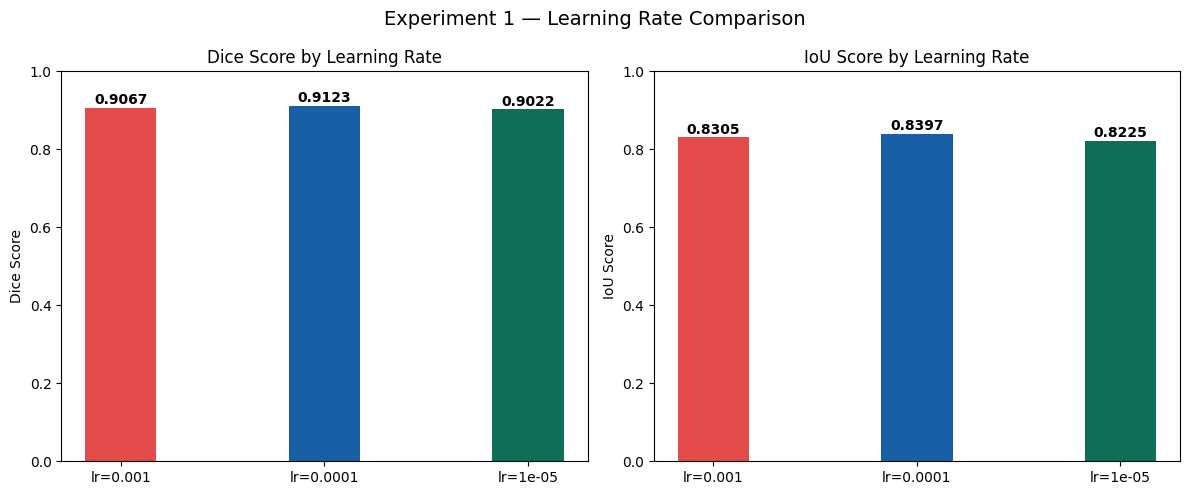

Chart saved to /content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_lr_comparison.png


In [ ]:
# Plot Experiment 1
labels      = [r['label']    for r in lr_results]
dice_scores = [r['val_dice'] for r in lr_results]
iou_scores  = [r['val_iou']  for r in lr_results]
x      = np.arange(len(labels))
width  = 0.35
colors = ['#E24B4A', '#185FA5', '#0F6E56']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars1 = axes[0].bar(x, dice_scores, width, color=colors)
axes[0].set_title('Dice Score by Learning Rate')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Dice Score')
axes[0].set_ylim(0, 1)
for bar, v in zip(bars1, dice_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(x, iou_scores, width, color=colors)
axes[1].set_title('IoU Score by Learning Rate')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('IoU Score')
axes[1].set_ylim(0, 1)
for bar, v in zip(bars2, iou_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Experiment 1 — Learning Rate Comparison', fontsize=14)
plt.tight_layout()
save_path = '/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_lr_comparison.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Chart saved to {save_path}')

### Experiment 2 — Loss Function Comparison

Compare BCE alone vs combined BCE + Dice. All other settings identical.

**Hypothesis:** BCE + Dice will outperform BCE alone because Dice handles the 86.1% background class imbalance.

In [ ]:
loss_configs = [
    {'label': 'BCE Only',   'bce_weight': 1.0, 'dice_weight': 0.0},
    {'label': 'BCE + Dice', 'bce_weight': 1.0, 'dice_weight': 1.0},
]
loss_results = []

for lc in loss_configs:
    print(f"\n{'='*50}")
    print(f"Loss: {lc['label']}")
    print(f"{'='*50}")

    model = UNet(
        in_channels  = cfg['model']['in_channels'],
        out_channels = cfg['model']['out_channels']
    ).to(device)

    criterion = BCEDiceLoss(bce_weight=lc['bce_weight'], dice_weight=lc['dice_weight'])
    optimizer = optim.Adam(model.parameters(), lr=cfg['training']['lr'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=cfg['training']['lr_patience'], factor=cfg['training']['lr_factor']
    )

    best_dice = 0.0
    best_iou  = 0.0

    for epoch in range(1, EXPERIMENT_EPOCHS + 1):
        trn_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        if val_dice > best_dice:
            best_dice = val_dice
            best_iou  = val_iou
        if epoch % 10 == 0 or epoch == EXPERIMENT_EPOCHS:
            print(f'  Epoch {epoch:>3} | Loss {val_loss:.4f} | Dice {val_dice:.4f} | IoU {val_iou:.4f}')

    loss_results.append({'label': lc['label'], 'val_dice': best_dice, 'val_iou': best_iou})
    print(f'  Best Dice: {best_dice:.4f} | Best IoU: {best_iou:.4f}')

print(f"\n{'='*50}")
print('Experiment 2 Summary')
print(f"{'Loss':>12} {'Dice':>8} {'IoU':>8}")
print('-' * 30)
for r in loss_results:
    print(f"{r['label']:>12} {r['val_dice']:>8.4f} {r['val_iou']:>8.4f}")
improvement = loss_results[1]['val_dice'] - loss_results[0]['val_dice']
print(f'\nBCE+Dice improvement over BCE alone: +{improvement:.4f} Dice')


Loss: BCE Only
  Epoch  10 | Loss 0.1877 | Dice 0.8856 | IoU 0.7983
  Epoch  20 | Loss 0.1042 | Dice 0.8983 | IoU 0.8180
  Epoch  30 | Loss 0.0904 | Dice 0.8997 | IoU 0.8206
  Best Dice: 0.9116 | Best IoU: 0.8384

Loss: BCE + Dice
  Epoch  10 | Loss 0.3798 | Dice 0.8910 | IoU 0.8054
  Epoch  20 | Loss 0.2784 | Dice 0.8953 | IoU 0.8119
  Epoch  30 | Loss 0.2048 | Dice 0.9097 | IoU 0.8353
  Best Dice: 0.9134 | Best IoU: 0.8416

Experiment 2 Summary
        Loss     Dice      IoU
------------------------------
    BCE Only   0.9116   0.8384
  BCE + Dice   0.9134   0.8416

BCE+Dice improvement over BCE alone: +0.0018 Dice


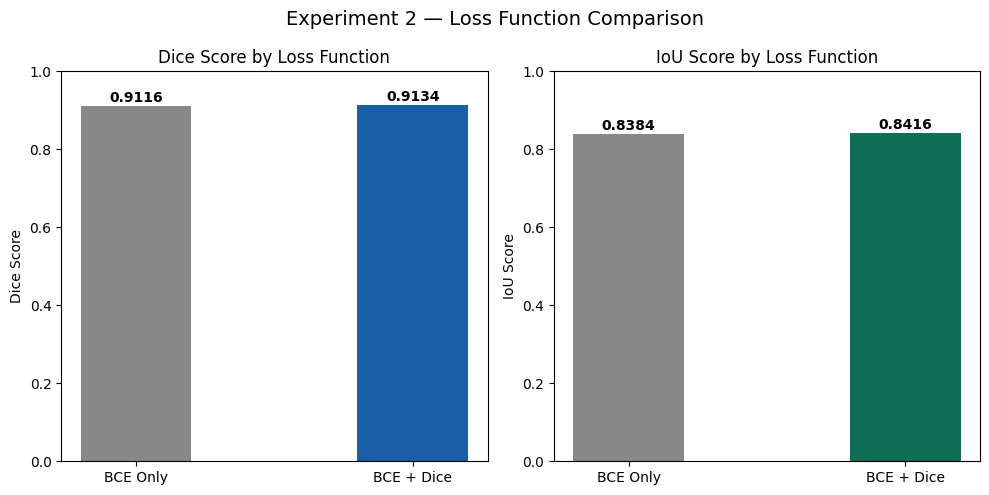

Chart saved to /content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_loss_comparison.png


In [ ]:
# Plot Experiment 2
labels      = [r['label']    for r in loss_results]
dice_scores = [r['val_dice'] for r in loss_results]
iou_scores  = [r['val_iou']  for r in loss_results]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
bars1 = axes[0].bar(labels, dice_scores, color=['#888888', '#185FA5'], width=0.4)
axes[0].set_title('Dice Score by Loss Function')
axes[0].set_ylabel('Dice Score')
axes[0].set_ylim(0, 1)
for bar, v in zip(bars1, dice_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(labels, iou_scores, color=['#888888', '#0F6E56'], width=0.4)
axes[1].set_title('IoU Score by Loss Function')
axes[1].set_ylabel('IoU Score')
axes[1].set_ylim(0, 1)
for bar, v in zip(bars2, iou_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Experiment 2 — Loss Function Comparison', fontsize=14)
plt.tight_layout()
save_path = '/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_loss_comparison.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Chart saved to {save_path}')

### Experiment 3 — Data Augmentation Effect

Compare training with and without augmentation. All other settings identical.

**Hypothesis:** Augmentation improves Dice by synthetically expanding the 469 training samples, reducing overfitting.

**Note:** Requires `train_data_noaug.npz` from Student A on Drive.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

def load_npz_loader(npz_path, batch_size=8, shuffle=True):
    data   = np.load(npz_path)
    images = torch.tensor(data['images'], dtype=torch.float32)
    masks  = torch.tensor(data['masks'],  dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(images, masks),
                      batch_size=batch_size, shuffle=shuffle,
                      pin_memory=True)

aug_configs = [
    {
        'label'      : 'Without Augmentation',
        'train_path' : '/content/drive/MyDrive/Medical_Segmentation_Data/preprocessed/train_preprocessed.npz'
    },
    {
        'label'      : 'With Augmentation',
        'train_path' : '/content/drive/MyDrive/Medical_Segmentation_Data/augmented/train_augmented.npz'
    },
]

val_ldr     = load_npz_loader(
    '/content/drive/MyDrive/Medical_Segmentation_Data/preprocessed/val_preprocessed.npz',
    shuffle=False
)
aug_results = []

for ac in aug_configs:
    print(f"\n{'='*50}")
    print(f"Setup: {ac['label']}")
    print(f"{'='*50}")

    if not os.path.exists(ac['train_path']):
        print(f"  SKIP: {ac['train_path']} not found")
        aug_results.append({'label': ac['label'], 'val_dice': None, 'val_iou': None})
        continue

    train_ldr = load_npz_loader(ac['train_path'], shuffle=True)
    print(f"  Loaded {len(train_ldr.dataset)} training samples")

    model = UNet(
        in_channels  = cfg['model']['in_channels'],
        out_channels = cfg['model']['out_channels']
    ).to(device)
    criterion = BCEDiceLoss(
        bce_weight  = cfg['loss']['bce_weight'],
        dice_weight = cfg['loss']['dice_weight']
    )
    optimizer = optim.Adam(model.parameters(), lr=cfg['training']['lr'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience = cfg['training']['lr_patience'],
        factor   = cfg['training']['lr_factor']
    )

    best_dice = 0.0
    best_iou  = 0.0

    for epoch in range(1, EXPERIMENT_EPOCHS + 1):
        trn_loss = train_one_epoch(model, train_ldr, optimizer, criterion, device)
        val_loss, val_dice, val_iou = validate(model, val_ldr, criterion, device)
        scheduler.step(val_loss)
        if val_dice > best_dice:
            best_dice = val_dice
            best_iou  = val_iou
        if epoch % 10 == 0 or epoch == EXPERIMENT_EPOCHS:
            print(f'  Epoch {epoch:>3} | Loss {val_loss:.4f} | '
                  f'Dice {val_dice:.4f} | IoU {val_iou:.4f}')

    aug_results.append({'label': ac['label'], 'val_dice': best_dice, 'val_iou': best_iou})
    print(f'  Best Dice: {best_dice:.4f} | Best IoU: {best_iou:.4f}')

print(f"\n{'='*50}")
print('Experiment 3 Summary')
print(f"{'Setup':<25} {'Dice':>8} {'IoU':>8}")
print('-' * 45)
for r in aug_results:
    if r['val_dice'] is not None:
        print(f"{r['label']:<25} {r['val_dice']:>8.4f} {r['val_iou']:>8.4f}")
    else:
        print(f"{r['label']:<25} {'N/A':>8}")


Setup: Without Augmentation
  Loaded 469 training samples
  Epoch  10 | Loss 0.5874 | Dice 0.9008 | IoU 0.8209
  Epoch  20 | Loss 0.3652 | Dice 0.9057 | IoU 0.8289
  Epoch  30 | Loss 0.2587 | Dice 0.9138 | IoU 0.8421
  Best Dice: 0.9138 | Best IoU: 0.8421

Setup: With Augmentation
  Loaded 2814 training samples
  Epoch  10 | Loss 0.1795 | Dice 0.9124 | IoU 0.8397
  Epoch  20 | Loss 0.1862 | Dice 0.9075 | IoU 0.8315
  Epoch  30 | Loss 0.1634 | Dice 0.9185 | IoU 0.8500
  Best Dice: 0.9185 | Best IoU: 0.8500

Experiment 3 Summary
Setup                         Dice      IoU
---------------------------------------------
Without Augmentation        0.9138   0.8421
With Augmentation           0.9185   0.8500


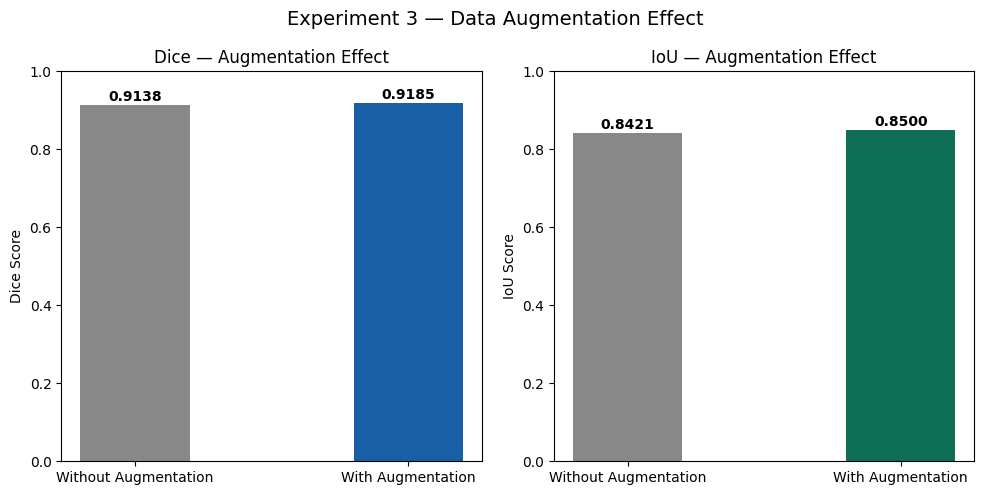

Chart saved to /content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_aug_comparison.png


In [ ]:
# Plot Experiment 3
valid = [r for r in aug_results if r['val_dice'] is not None]

if len(valid) == 2:
    labels      = [r['label']    for r in valid]
    dice_scores = [r['val_dice'] for r in valid]
    iou_scores  = [r['val_iou']  for r in valid]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    bars1 = axes[0].bar(labels, dice_scores, color=['#888888', '#185FA5'], width=0.4)
    axes[0].set_title('Dice — Augmentation Effect')
    axes[0].set_ylabel('Dice Score')
    axes[0].set_ylim(0, 1)
    for bar, v in zip(bars1, dice_scores):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

    bars2 = axes[1].bar(labels, iou_scores, color=['#888888', '#0F6E56'], width=0.4)
    axes[1].set_title('IoU — Augmentation Effect')
    axes[1].set_ylabel('IoU Score')
    axes[1].set_ylim(0, 1)
    for bar, v in zip(bars2, iou_scores):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

    plt.suptitle('Experiment 3 — Data Augmentation Effect', fontsize=14)
    plt.tight_layout()
    save_path = '/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/experiment_aug_comparison.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Chart saved to {save_path}')
else:
    print('Skipping plot — train_data_noaug.npz not available from Student A.')

## 6. Final Evaluation on Test Set

Evaluate the best trained model on the held-out test set (101 images).
This data was never seen during training or validation.
These are the final official results reported in the paper.

In [ ]:
# Load best model weights
best_model_path = '/content/Medical-Image-Segmentation-with-UNet-Variants/checkpoints/best_model.pth'

if not os.path.exists(best_model_path):
    drive_path = '/content/drive/MyDrive/Medical_Segmentation_Data/checkpoints/best_model.pth'
    if os.path.exists(drive_path):
        import shutil
        shutil.copy(drive_path, best_model_path)
        print('Loaded model weights from Drive')
    else:
        print('ERROR: best_model.pth not found. Run Section 3 first.')

final_model = UNet(
    in_channels  = cfg['model']['in_channels'],
    out_channels = cfg['model']['out_channels']
).to(device)
final_model.load_state_dict(torch.load(best_model_path, map_location=device))
final_model.eval()
print('Best model loaded.')

Loaded model weights from Drive
Best model loaded.


In [ ]:
# Evaluate on test set
total_dice = 0.0
total_iou  = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks  = masks.to(device)
        preds  = final_model(images)
        total_dice += dice_score(preds, masks).item()
        total_iou  += iou_score(preds,  masks).item()

n         = len(test_loader)
test_dice = total_dice / n
test_iou  = total_iou  / n

print('=' * 40)
print('Final Test Set Results')
print('Model   : UNet')
print('Subset  : Test (101 images)')
print('=' * 40)
print(f'Test Dice : {test_dice:.4f}')
print(f'Test IoU  : {test_iou:.4f}')

with open('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/metrics_test.txt', 'w') as f:
    f.write('=' * 40 + '\n')
    f.write('Final Test Set Results\n')
    f.write('Model   : UNet\n')
    f.write('Dataset : 2018 Data Science Bowl\n')
    f.write('Subset  : Test (101 images)\n')
    f.write('=' * 40 + '\n\n')
    f.write(f'test_dice : {test_dice:.4f}\n')
    f.write(f'test_iou  : {test_iou:.4f}\n')

print('\nSaved to reports/figures/metrics_test.txt')

Final Test Set Results
Model   : UNet
Subset  : Test (101 images)
Test Dice : 0.9235
Test IoU  : 0.8591

Saved to reports/figures/metrics_test.txt
